# 🛍️ Product Image Classification Framework
### CNN-Based E-Commerce Product Categorization
**Dataset:** [Fashion Products Images – Kaggle](https://www.kaggle.com/datasets/bhavikjikadara/e-commerce-products-images)  
**Framework:** TensorFlow / Keras  
**Phase 2 – Code Implementation**

---
## 📦 Step 1: Install & Import Libraries

In [1]:
# ── Core libraries ──────────────────────────────────────────────────────────
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from collections import Counter

warnings.filterwarnings('ignore')

# ── Image / CV ───────────────────────────────────────────────────────────────
import cv2
from PIL import Image

# ── TensorFlow / Keras ───────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    VGG16, ResNet50, MobileNetV2, EfficientNetB0
)
from tensorflow.keras.applications.vgg16        import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50     import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2  import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet  import preprocess_input as efficientnet_preprocess

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc,
    f1_score, accuracy_score
)
from sklearn.preprocessing import label_binarize

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPUs available     : {tf.config.list_physical_devices('GPU')}")

2026-06-08 20:45:20.195537: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780951520.367836      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780951520.420616      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780951520.821074      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780951520.821117      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780951520.821120      23 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPUs available     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 📂 Step 2: Dataset Loading & Exploration

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Dataset structure:
#   /kaggle/input/e-commerce-products-images/
#       styles.csv
#       e-commerce/
#           images/
#               15970.jpg  ...  (all product images)

BASE_DIR   = Path('/kaggle/input/datasets/bhavikjikadara/e-commerce-products-images')
IMAGE_DIR  = BASE_DIR / 'e-commerce' / 'images'   # actual image folder
OUTPUT_DIR = Path('/kaggle/working/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Verify paths exist
print(f"BASE_DIR  exists : {BASE_DIR.exists()}")
print(f"IMAGE_DIR exists : {IMAGE_DIR.exists()}")
print(f"OUTPUT_DIR       : {OUTPUT_DIR}")

# List top-level contents
print("\nDataset top-level contents:")
for p in sorted(BASE_DIR.iterdir()):
    print(f"  {p.name}")

BASE_DIR  exists : True
IMAGE_DIR exists : True
OUTPUT_DIR       : /kaggle/working/outputs

Dataset top-level contents:
  e-commerce
  styles.csv


In [3]:
# ── Load styles.csv ───────────────────────────────────────────────────────────
# on_bad_lines='skip' handles the few malformed rows in this dataset
df = pd.read_csv(BASE_DIR / 'styles.csv', on_bad_lines='skip')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (44441, 10)
Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [4]:
# ── Basic info ────────────────────────────────────────────────────────────────
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44441 entries, 0 to 44440
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44441 non-null  int64  
 1   gender              44441 non-null  object 
 2   masterCategory      44441 non-null  object 
 3   subCategory         44441 non-null  object 
 4   articleType         44441 non-null  object 
 5   baseColour          44426 non-null  object 
 6   season              44420 non-null  object 
 7   year                44440 non-null  float64
 8   usage               44124 non-null  object 
 9   productDisplayName  44434 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB
None

Missing values:
id                      0
gender                  0
masterCategory          0
subCategory             0
articleType             0
baseColour             15
season                 21
year                    1
usage      

In [5]:
# ── Build image paths & filter to existing files ──────────────────────────────
# Label column: 'masterCategory' (Apparel, Accessories, Footwear, etc.)
# Image filenames match the 'id' column  e.g. 15970 → 15970.jpg
LABEL_COL = 'masterCategory'

df['image_path'] = df['id'].astype(str).apply(
    lambda x: str(IMAGE_DIR / f"{x}.jpg")
)

# Keep only rows whose image actually exists on disk
df['exists'] = df['image_path'].apply(os.path.exists)
df = df[df['exists']].drop(columns='exists').reset_index(drop=True)
print(f"Images found on disk: {len(df):,}")

Images found on disk: 44,441


Number of classes : 7
masterCategory
Apparel           21395
Accessories       11289
Footwear           9222
Personal Care      2404
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64


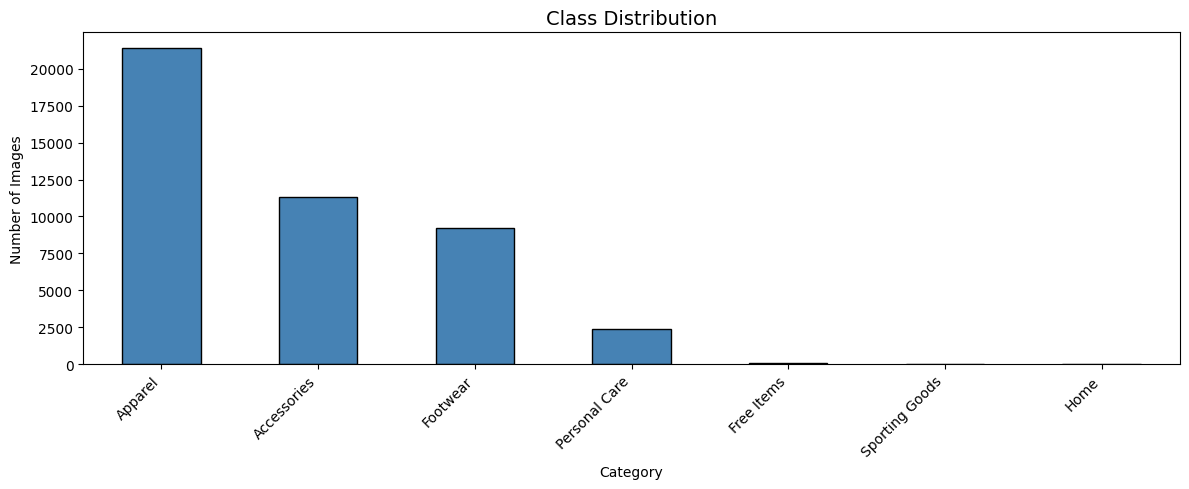

In [6]:
# ── Class distribution ────────────────────────────────────────────────────────
class_counts = df[LABEL_COL].value_counts()
print(f"Number of classes : {len(class_counts)}")
print(class_counts)

plt.figure(figsize=(12, 5))
class_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.pdf', dpi=150)
plt.show()

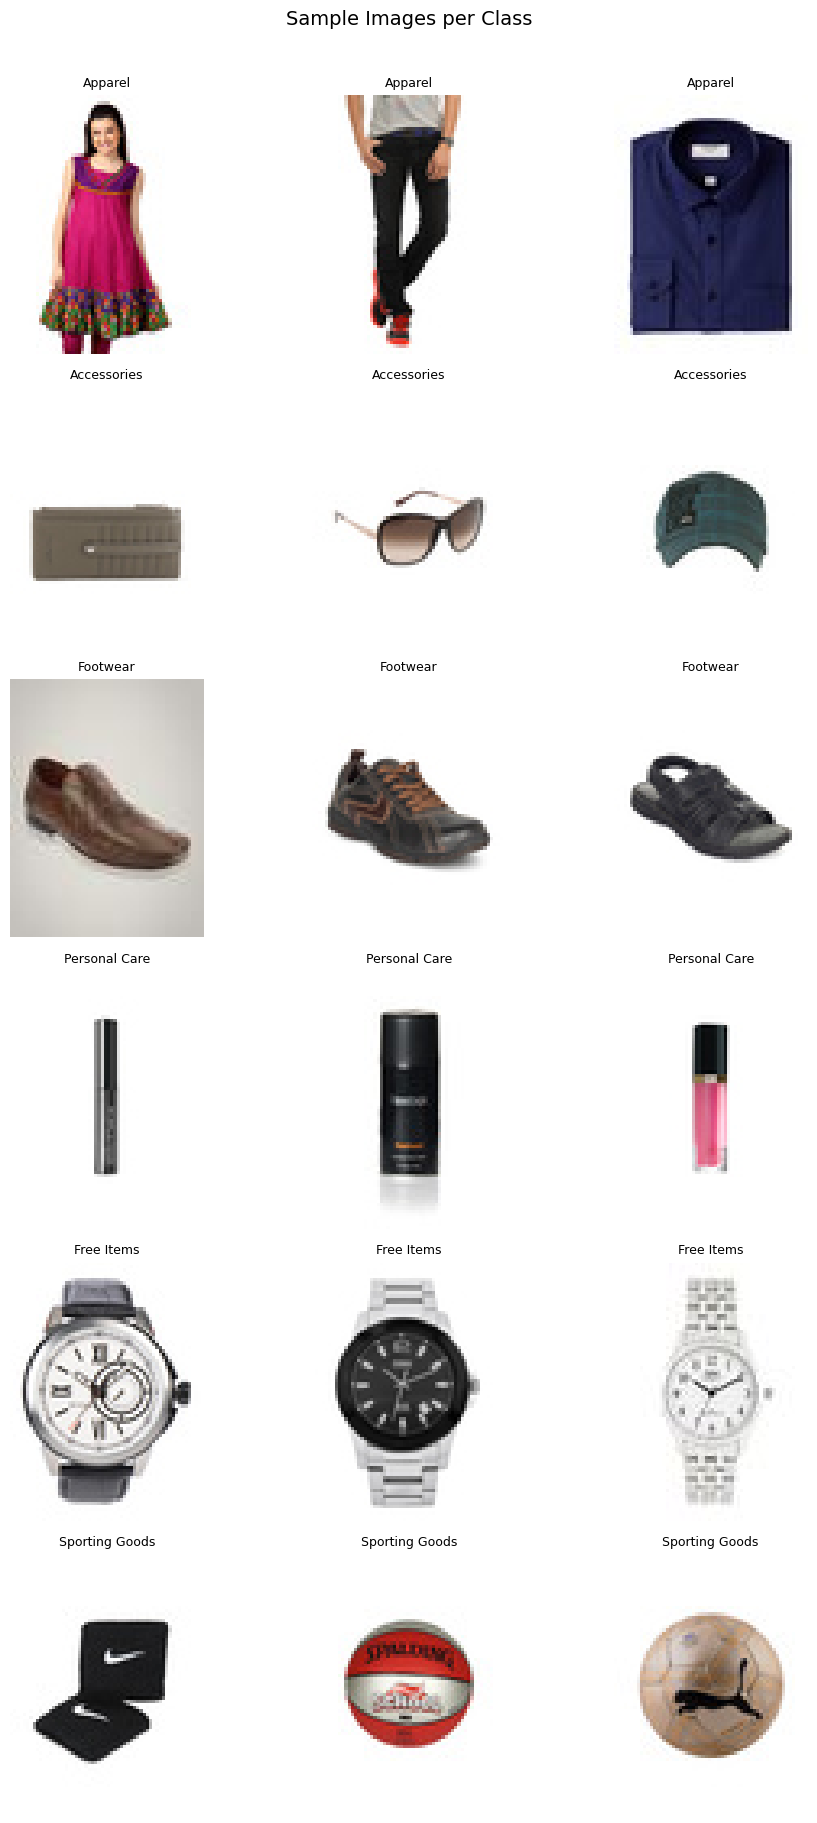

In [7]:
# ── Sample images per class ───────────────────────────────────────────────────
classes   = class_counts.index.tolist()
n_classes = len(classes)

fig, axes = plt.subplots(min(n_classes, 6), 3, figsize=(10, min(n_classes, 6) * 3))
axes = axes.flatten()

ax_idx = 0
for cls in classes[:6]:          # show up to 6 classes
    samples = df[df[LABEL_COL] == cls].sample(3, random_state=SEED)
    for _, row in samples.iterrows():
        img = Image.open(row['image_path']).convert('RGB')
        axes[ax_idx].imshow(img)
        axes[ax_idx].set_title(cls, fontsize=9)
        axes[ax_idx].axis('off')
        ax_idx += 1

plt.suptitle('Sample Images per Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_images.pdf', dpi=150, bbox_inches='tight')
plt.show()

---
## ✂️ Step 3: Preprocessing & Train / Val / Test Split

In [8]:
# ── Configuration ─────────────────────────────────────────────────────────────
IMG_SIZE   = (128, 128)   # resize all images to this resolution
BATCH_SIZE = 32
EPOCHS_CNN = 30           # custom CNN training epochs
EPOCHS_TL  = 20           # transfer learning epochs

# ── Keep only classes with enough samples ─────────────────────────────────────
MIN_SAMPLES   = 50
valid_classes = class_counts[class_counts >= MIN_SAMPLES].index.tolist()
df_filtered   = df[df[LABEL_COL].isin(valid_classes)].copy().reset_index(drop=True)
print(f"Classes kept : {len(valid_classes)}  →  {valid_classes}")
print(f"Images kept  : {len(df_filtered):,}")

NUM_CLASSES = len(valid_classes)
CLASS_NAMES = sorted(valid_classes)

Classes kept : 5  →  ['Apparel', 'Accessories', 'Footwear', 'Personal Care', 'Free Items']
Images kept  : 44,415


In [9]:
# ── Encode labels ─────────────────────────────────────────────────────────────
label2idx = {c: i for i, c in enumerate(CLASS_NAMES)}
idx2label = {i: c for c, i in label2idx.items()}
df_filtered['label'] = df_filtered[LABEL_COL].map(label2idx)

# ── Stratified 70 / 15 / 15 split ────────────────────────────────────────────
train_df, temp_df = train_test_split(
    df_filtered, test_size=0.30, stratify=df_filtered['label'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED
)

print(f"Train : {len(train_df):,}")
print(f"Val   : {len(val_df):,}")
print(f"Test  : {len(test_df):,}")

Train : 31,090
Val   : 6,662
Test  : 6,663


In [10]:
# ── Data Augmentation (training only) ────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Validation / test: only rescale (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1.0/255)

# ── Helper: create a flow_from_dataframe generator ───────────────────────────
def make_generator(datagen, dataframe, shuffle=True):
    return datagen.flow_from_dataframe(
        dataframe=dataframe,
        x_col='image_path',
        y_col=LABEL_COL,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=CLASS_NAMES,
        shuffle=shuffle,
        seed=SEED
    )

train_gen = make_generator(train_datagen,    train_df, shuffle=True)
val_gen   = make_generator(val_test_datagen, val_df,   shuffle=False)
test_gen  = make_generator(val_test_datagen, test_df,  shuffle=False)

print("Class indices:", train_gen.class_indices)

Found 31090 validated image filenames belonging to 5 classes.
Found 6662 validated image filenames belonging to 5 classes.
Found 6663 validated image filenames belonging to 5 classes.
Class indices: {'Accessories': 0, 'Apparel': 1, 'Footwear': 2, 'Free Items': 3, 'Personal Care': 4}


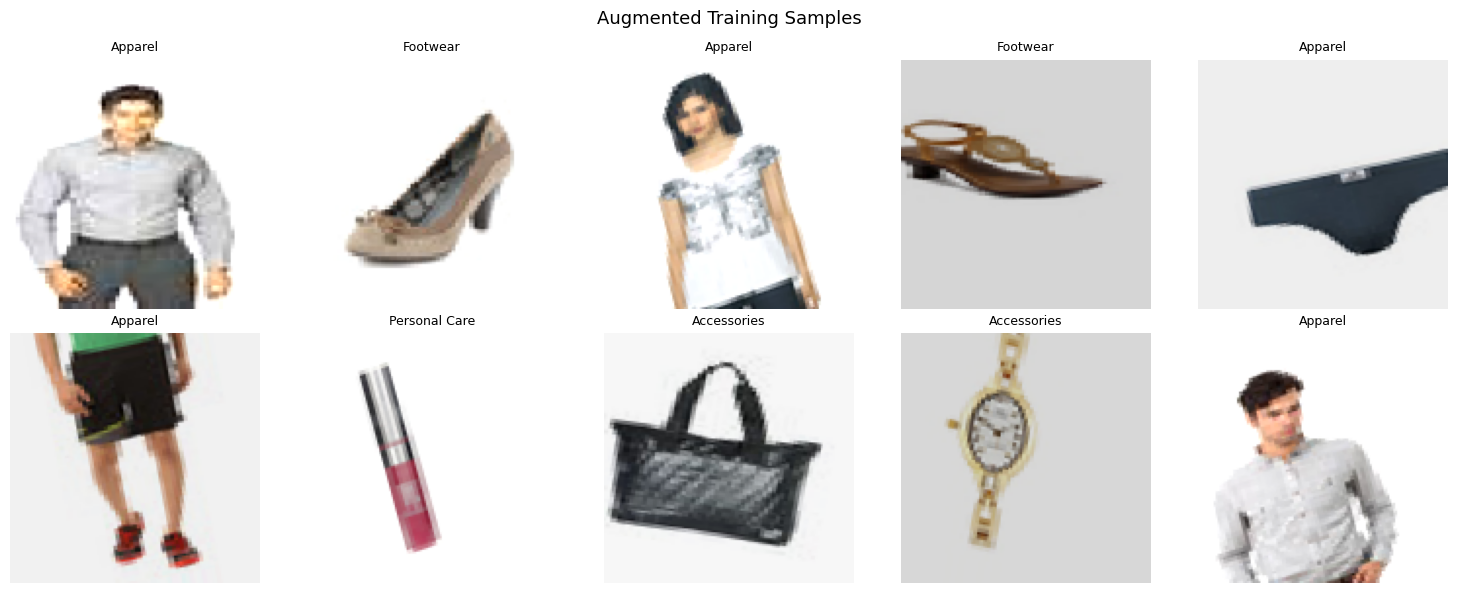

In [11]:
# ── Visualize augmented training samples ─────────────────────────────────────
batch_images, batch_labels = next(train_gen)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(batch_images[i])
    ax.set_title(CLASS_NAMES[np.argmax(batch_labels[i])], fontsize=9)
    ax.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'augmented_samples.pdf', dpi=150)
plt.show()

---
## 🧠 Step 4: Custom CNN Model

In [12]:
def build_custom_cnn(input_shape, num_classes):
    """
    Custom CNN with 4 convolutional blocks:
      - Conv → BatchNorm → ReLU → Conv → BatchNorm → ReLU → MaxPool → Dropout
      - Global Average Pooling (reduces overfitting vs Flatten)
      - Dense head with L2 regularization and Dropout
    """
    model = models.Sequential(name='Custom_CNN')

    # ── Block 1: 32 filters ───────────────────────────────────────────────────
    model.add(layers.Conv2D(32, (3,3), padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(32, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    # ── Block 2: 64 filters ───────────────────────────────────────────────────
    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    # ── Block 3: 128 filters ──────────────────────────────────────────────────
    model.add(layers.Conv2D(128, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.30))

    # ── Block 4: 256 filters ──────────────────────────────────────────────────
    model.add(layers.Conv2D(256, (3,3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.30))

    # ── Classification head ───────────────────────────────────────────────────
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.Dropout(0.50))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


INPUT_SHAPE = IMG_SIZE + (3,)          # (128, 128, 3)
cnn_model   = build_custom_cnn(INPUT_SHAPE, NUM_CLASSES)
cnn_model.summary()

I0000 00:00:1780951609.923343      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             

 Total params: 652,069 (2.49 MB)

 Trainable params: 650,661 (2.48 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [13]:
# ── Compile ───────────────────────────────────────────────────────────────────
cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ── Callbacks ────────────────────────────────────────────────────────────────
cnn_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / 'best_cnn_model.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1
    )
]

In [14]:
# ── Train the custom CNN ──────────────────────────────────────────────────────
cnn_history = cnn_model.fit(
    train_gen,
    epochs=EPOCHS_CNN,
    validation_data=val_gen,
    callbacks=cnn_callbacks,
    verbose=1
)

print("\nCustom CNN training complete.")

Epoch 1/30


I0000 00:00:1780951616.650469      70 service.cc:152] XLA service 0x79f4ec003ac0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780951616.650511      70 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780951617.621914      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/972 ━━━━━━━━━━━━━━━━━━━━ 3:55:40 15s/step - accuracy: 0.3438 - loss: 1.9267

I0000 00:00:1780951626.497383      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.7116 - loss: 0.7404
Epoch 1: val_accuracy improved from None to 0.57595, saving model to /kaggle/working/outputs/best_cnn_model.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_cnn_model.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 247s 239ms/step - accuracy: 0.7803 - loss: 0.5911 - val_accuracy: 0.5760 - val_loss: 3.9919 - learning_rate: 0.0010
Epoch 2/30
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8660 - loss: 0.4082
Epoch 2: val_accuracy improved from 0.57595 to 0.65026, saving model to /kaggle/working/outputs/best_cnn_model.keras

Epoch 2: finished saving model to /kaggle/working/outputs/best_cnn_model.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 169s 174ms/step - accuracy: 0.8751 - loss: 0.3875 - val_accuracy: 0.6503 - val_loss: 1.5371 - learning_rate: 0.0010
Epoch 3/30
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9002 - loss: 0.3293
Epoch 3: val_accuracy did not improve from 0.65026
972/972 ━━━━━━━

---
## 📈 Step 5: Training Curves

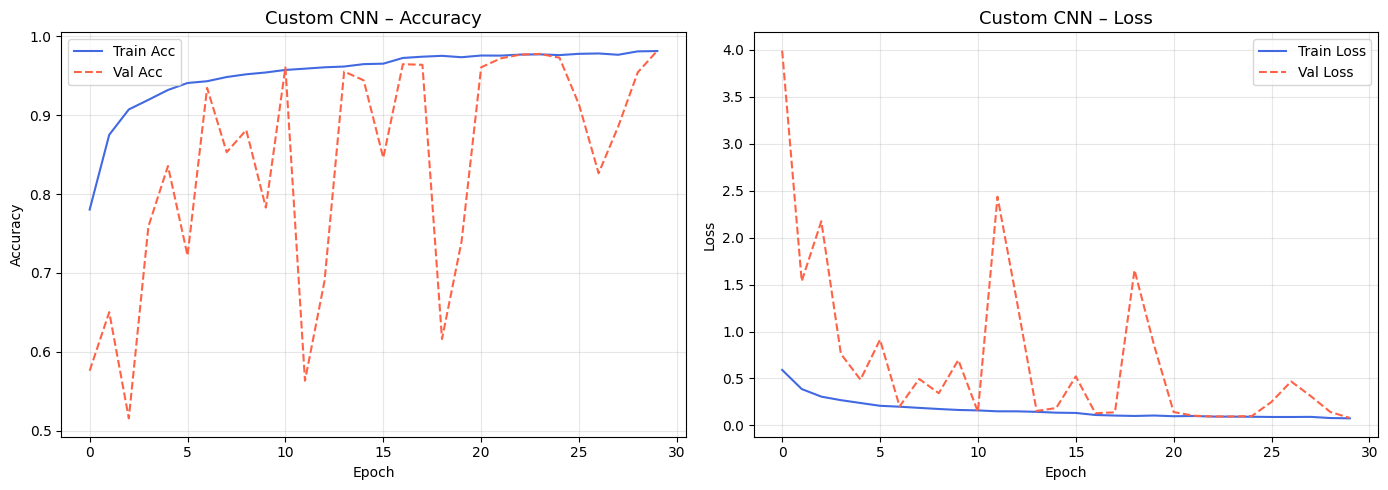

In [15]:
def plot_history(history, title, save_path):
    """Plot accuracy and loss curves side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     label='Train Acc', color='royalblue')
    ax1.plot(history.history['val_accuracy'], label='Val Acc',   color='tomato', linestyle='--')
    ax1.set_title(f'{title} – Accuracy', fontsize=13)
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train Loss', color='royalblue')
    ax2.plot(history.history['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
    ax2.set_title(f'{title} – Loss', fontsize=13)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


plot_history(cnn_history, 'Custom CNN', OUTPUT_DIR / 'cnn_training_curves.pdf')

---
## 📊 Step 6: Evaluate Custom CNN on Test Set

209/209 ━━━━━━━━━━━━━━━━━━━━ 31s 146ms/step

  Custom_CNN – Classification Report
               precision    recall  f1-score   support

  Accessories     0.9616    0.9764    0.9690      1694
      Apparel     0.9912    0.9872    0.9892      3210
     Footwear     0.9885    0.9964    0.9924      1384
   Free Items     0.0000    0.0000    0.0000        15
Personal Care     0.9801    0.9556    0.9677       360

     accuracy                         0.9824      6663
    macro avg     0.7843    0.7831    0.7837      6663
 weighted avg     0.9803    0.9824    0.9813      6663



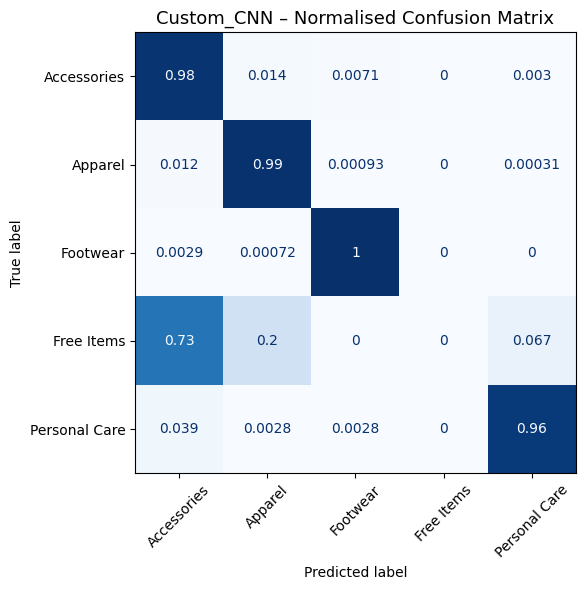

Test Accuracy : 0.9824
Macro F1      : 0.7837


In [16]:
def evaluate_model(model, test_generator, class_names, model_name, output_dir):
    """
    Full evaluation pipeline:
      1. Predict on test set
      2. Print & save classification report
      3. Plot normalised confusion matrix
    Returns dict with accuracy, macro-F1, raw predictions.
    """
    test_generator.reset()
    y_prob = model.predict(test_generator, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = test_generator.classes

    # Classification report
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(f"\n{'='*60}")
    print(f"  {model_name} – Classification Report")
    print('='*60)
    print(report)
    report_dict = classification_report(
        y_true, y_pred, target_names=class_names, digits=4, output_dict=True)
    report_df = pd.DataFrame(report_dict).T.round(4)
    report_df.to_csv(output_dir / f'{model_name}_report.csv')

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    fig, ax = plt.subplots(figsize=(max(8, len(class_names)), max(6, len(class_names)-2)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'{model_name} – Normalised Confusion Matrix', fontsize=13)
    plt.tight_layout()
    plt.savefig(output_dir / f'{model_name}_confusion_matrix.pdf', dpi=150, bbox_inches='tight')
    plt.show()

    # Summary
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    print(f"Test Accuracy : {acc:.4f}")
    print(f"Macro F1      : {f1:.4f}")

    return {'accuracy': acc, 'macro_f1': f1,
            'y_prob': y_prob, 'y_pred': y_pred, 'y_true': y_true}


cnn_results = evaluate_model(cnn_model, test_gen, CLASS_NAMES, 'Custom_CNN', OUTPUT_DIR)

---
## 🔁 Step 7: Transfer Learning – MobileNetV2

In [17]:
def build_transfer_model(base_fn, preprocess_fn, input_shape, num_classes, name='TL_Model'):
    """
    Builds a transfer learning model:
      - Pretrained base with ImageNet weights (top excluded)
      - Base frozen for initial feature extraction
      - Custom dense classification head
    """
    base_model = base_fn(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False   # freeze base initially

    inputs  = keras.Input(shape=input_shape)
    x       = preprocess_fn(inputs)           # backbone-specific normalisation
    x       = base_model(x, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu',
                            kernel_regularizer=regularizers.l2(1e-4))(x)
    x       = layers.Dropout(0.50)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name=name)


# ── MobileNetV2 ───────────────────────────────────────────────────────────────
mobilenet_model = build_transfer_model(
    MobileNetV2, mobilenet_preprocess, INPUT_SHAPE, NUM_CLASSES, name='MobileNetV2'
)
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
# ── Generators for transfer learning models ───────────────────────────────────
# NOTE: backbone preprocess_input handles normalisation; do NOT add rescale=1/255
tl_train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
tl_val_datagen = ImageDataGenerator()   # no rescale; handled inside model

tl_train_gen = make_generator(tl_train_datagen, train_df, shuffle=True)
tl_val_gen   = make_generator(tl_val_datagen,   val_df,   shuffle=False)
tl_test_gen  = make_generator(tl_val_datagen,   test_df,  shuffle=False)

Found 31090 validated image filenames belonging to 5 classes.
Found 6662 validated image filenames belonging to 5 classes.
Found 6663 validated image filenames belonging to 5 classes.


Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9273 - loss: 0.2868
Epoch 1: val_accuracy improved from None to 0.96953, saving model to /kaggle/working/outputs/best_mobilenet.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_mobilenet.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 203s 196ms/step - accuracy: 0.9532 - loss: 0.2015 - val_accuracy: 0.9695 - val_loss: 0.1454 - learning_rate: 0.0010
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9676 - loss: 0.1565
Epoch 2: val_accuracy improved from 0.96953 to 0.97523, saving model to /kaggle/working/outputs/best_mobilenet.keras

Epoch 2: finished saving model to /kaggle/working/outputs/best_mobilenet.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 184s 190ms/step - accuracy: 0.9696 - loss: 0.1522 - val_accuracy: 0.9752 - val_loss: 0.1388 - learning_rate: 0.0010
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9733 - loss: 0.1390
Epoch 3: val_accuracy improved from 0.97523 to 0.98034,

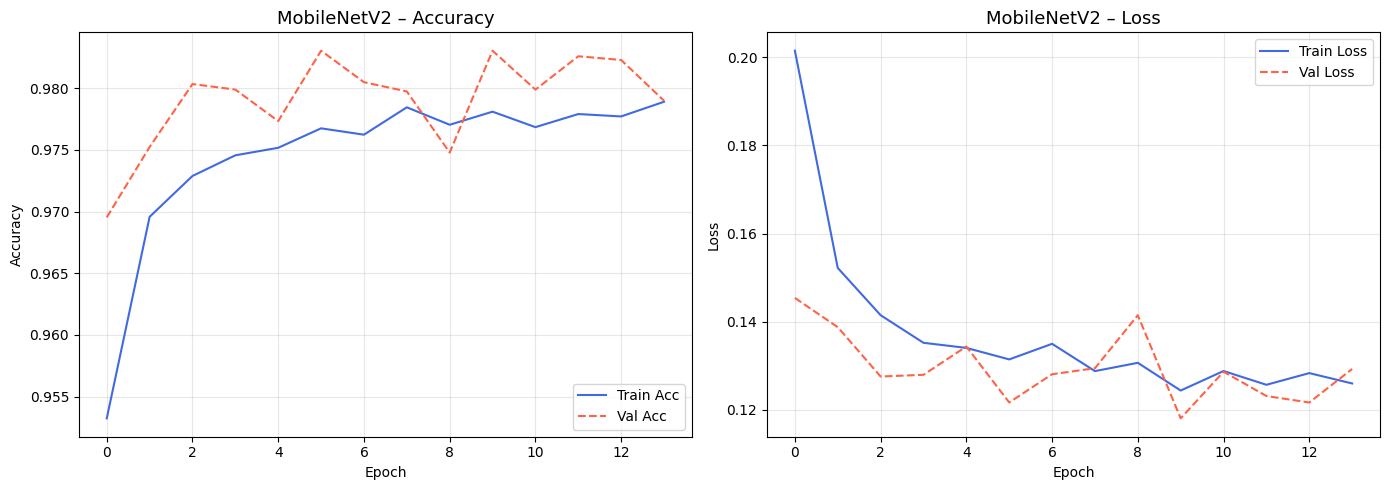

In [19]:
# ── Phase 1: Feature Extraction (base frozen) ─────────────────────────────────
mobilenet_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_callbacks = [
    callbacks.ModelCheckpoint(
        str(OUTPUT_DIR / 'best_mobilenet.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
                             restore_best_weights=True, verbose=1)
]

mobilenet_history = mobilenet_model.fit(
    tl_train_gen, epochs=EPOCHS_TL,
    validation_data=tl_val_gen,
    callbacks=tl_callbacks, verbose=1
)

plot_history(mobilenet_history, 'MobileNetV2', OUTPUT_DIR / 'mobilenet_training_curves.pdf')

Epoch 1/10


2026-06-08 22:50:54.213529: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-08 22:50:54.411512: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


569/972 ━━━━━━━━━━━━━━━━━━━━ 1:08 170ms/step - accuracy: 0.9324 - loss: 0.2666

2026-06-08 22:52:38.465899: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-08 22:52:38.667171: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9402 - loss: 0.2431
Epoch 1: val_accuracy did not improve from 0.98304
972/972 ━━━━━━━━━━━━━━━━━━━━ 203s 191ms/step - accuracy: 0.9546 - loss: 0.1989 - val_accuracy: 0.9803 - val_loss: 0.1331 - learning_rate: 1.0000e-05
Epoch 2/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9695 - loss: 0.1520
Epoch 2: val_accuracy did not improve from 0.98304
972/972 ━━━━━━━━━━━━━━━━━━━━ 161s 165ms/step - accuracy: 0.9707 - loss: 0.1482 - val_accuracy: 0.9811 - val_loss: 0.1277 - learning_rate: 1.0000e-05
Epoch 3/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.9744 - loss: 0.1353
Epoch 3: val_accuracy did not improve from 0.98304
972/972 ━━━━━━━━━━━━━━━━━━━━ 162s 166ms/step - accuracy: 0.9756 - loss: 0.1318 - val_accuracy: 0.9812 - val_loss: 0.1229 - learning_rate: 1.0000e-05
Epoch 4/10
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.9790 - loss: 0.1200
Epoch 4: val_accuracy did not improve from 0.98304
972/972 

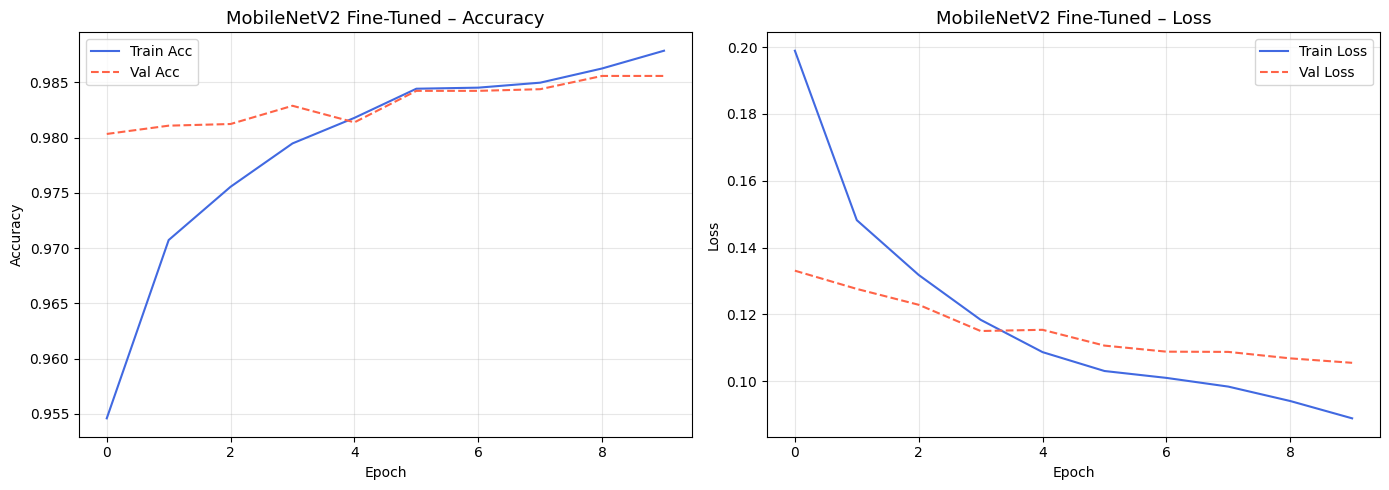

In [20]:
# ── Phase 2: Fine-Tuning (unfreeze top 30 layers of base) ────────────────────
# Find the MobileNetV2 base layer by name (safer than using index)
base_layer = mobilenet_model.get_layer('mobilenetv2_1.00_128')
base_layer.trainable = True
for layer in base_layer.layers[:-30]:
    layer.trainable = False

# Recompile with a much lower LR to avoid destroying pretrained weights
mobilenet_model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

finetune_history = mobilenet_model.fit(
    tl_train_gen, epochs=10,
    validation_data=tl_val_gen,
    callbacks=tl_callbacks, verbose=1
)

plot_history(finetune_history, 'MobileNetV2 Fine-Tuned',
             OUTPUT_DIR / 'mobilenet_finetune_curves.pdf')

209/209 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step

  MobileNetV2 – Classification Report
               precision    recall  f1-score   support

  Accessories     0.9698    0.9858    0.9778      1694
      Apparel     0.9938    0.9947    0.9942      3210
     Footwear     0.9985    0.9906    0.9946      1384
   Free Items     0.0000    0.0000    0.0000        15
Personal Care     0.9746    0.9611    0.9678       360

     accuracy                         0.9875      6663
    macro avg     0.7874    0.7865    0.7869      6663
 weighted avg     0.9854    0.9875    0.9864      6663



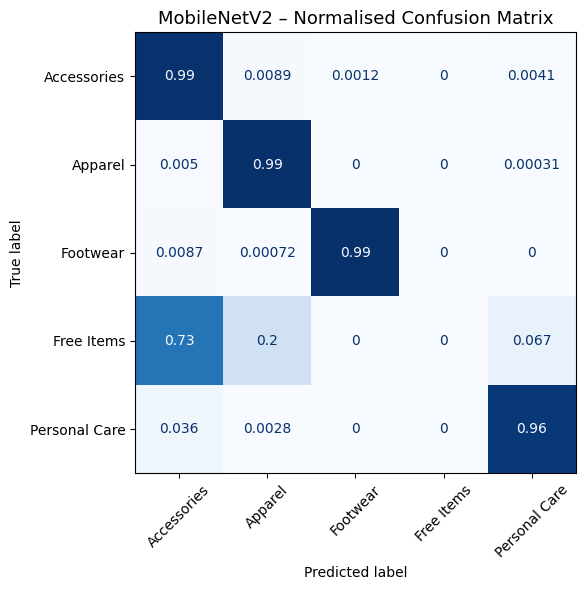

Test Accuracy : 0.9875
Macro F1      : 0.7869


In [21]:
mobilenet_results = evaluate_model(
    mobilenet_model, tl_test_gen, CLASS_NAMES, 'MobileNetV2', OUTPUT_DIR
)

---
## 🔁 Step 8: Transfer Learning – EfficientNetB0

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9456 - loss: 0.2201
Epoch 1: val_accuracy improved from None to 0.98259, saving model to /kaggle/working/outputs/best_efficientnet.keras

Epoch 1: finished saving model to /kaggle/working/outputs/best_efficientnet.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 197s 183ms/step - accuracy: 0.9659 - loss: 0.1646 - val_accuracy: 0.9826 - val_loss: 0.1190 - learning_rate: 0.0010
Epoch 2/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9782 - loss: 0.1265
Epoch 2: val_accuracy improved from 0.98259 to 0.98334, saving model to /kaggle/working/outputs/best_efficientnet.keras

Epoch 2: finished saving model to /kaggle/working/outputs/best_efficientnet.keras
972/972 ━━━━━━━━━━━━━━━━━━━━ 156s 160ms/step - accuracy: 0.9783 - loss: 0.1260 - val_accuracy: 0.9833 - val_loss: 0.1215 - learning_rate: 0.0010
Epoch 3/20
972/972 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.9773 - loss:

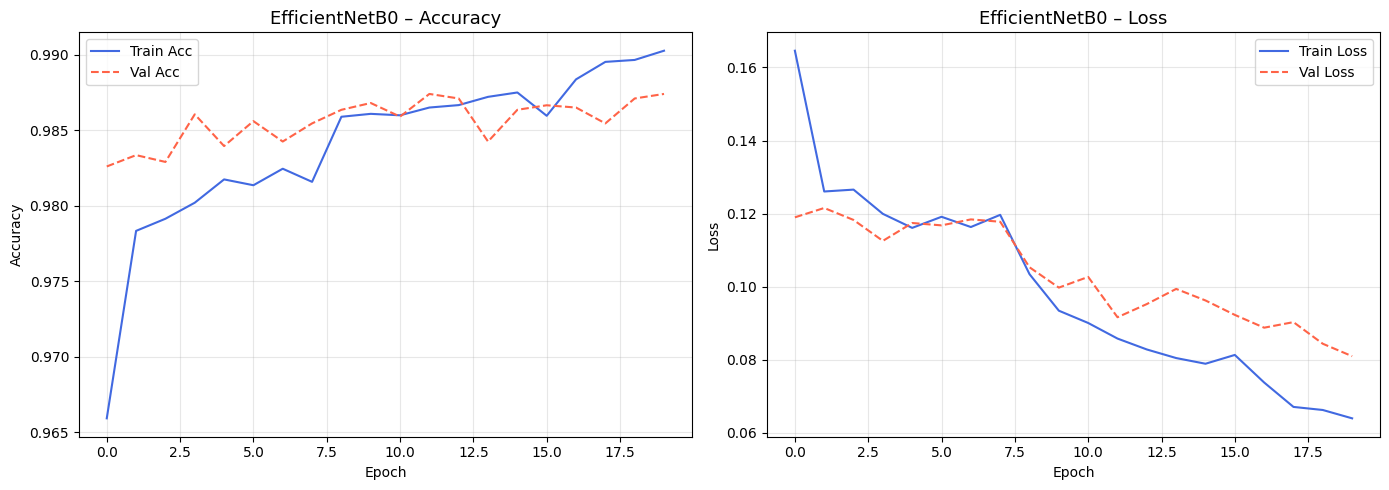

209/209 ━━━━━━━━━━━━━━━━━━━━ 28s 105ms/step

  EfficientNetB0 – Classification Report
               precision    recall  f1-score   support

  Accessories     0.9851    0.9782    0.9816      1694
      Apparel     0.9910    0.9947    0.9928      3210
     Footwear     0.9978    0.9986    0.9982      1384
   Free Items     0.0000    0.0000    0.0000        15
Personal Care     0.9492    0.9861    0.9673       360

     accuracy                         0.9886      6663
    macro avg     0.7846    0.7915    0.7880      6663
 weighted avg     0.9864    0.9886    0.9875      6663



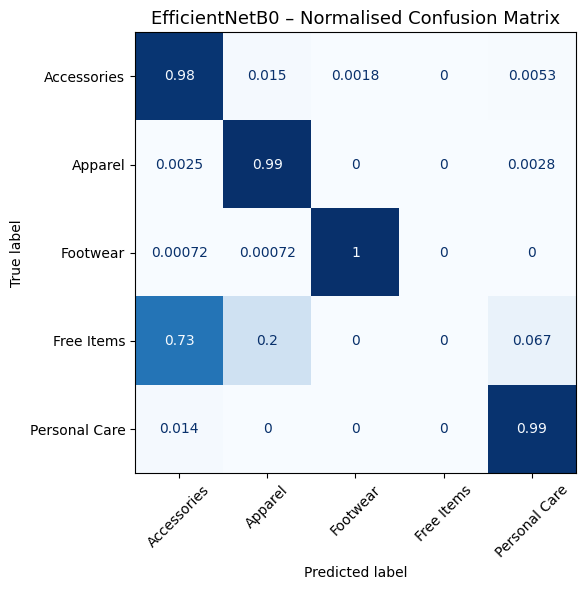

Test Accuracy : 0.9886
Macro F1      : 0.7880


In [22]:
efficientnet_model = build_transfer_model(
    EfficientNetB0, efficientnet_preprocess, INPUT_SHAPE, NUM_CLASSES, name='EfficientNetB0'
)

efficientnet_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

eff_callbacks = [
    callbacks.ModelCheckpoint(
        str(OUTPUT_DIR / 'best_efficientnet.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
                             restore_best_weights=True, verbose=1)
]

efficientnet_history = efficientnet_model.fit(
    tl_train_gen, epochs=EPOCHS_TL,
    validation_data=tl_val_gen,
    callbacks=eff_callbacks, verbose=1
)

plot_history(efficientnet_history, 'EfficientNetB0',
             OUTPUT_DIR / 'efficientnet_training_curves.pdf')

efficientnet_results = evaluate_model(
    efficientnet_model, tl_test_gen, CLASS_NAMES, 'EfficientNetB0', OUTPUT_DIR
)

---
## 📊 Step 9: Model Comparison Table

         Model Test Accuracy Macro F1 Parameters
    Custom CNN        0.9824   0.7837    652,069
   MobileNetV2        0.9875   0.7869  2,587,205
EfficientNetB0        0.9886   0.7880  4,378,792


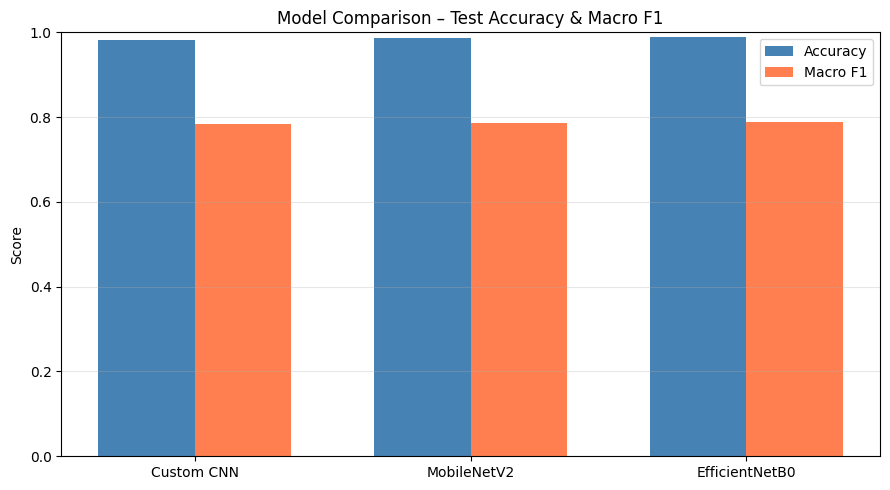

In [23]:
comparison = pd.DataFrame({
    'Model': ['Custom CNN', 'MobileNetV2', 'EfficientNetB0'],
    'Test Accuracy': [
        cnn_results['accuracy'],
        mobilenet_results['accuracy'],
        efficientnet_results['accuracy']
    ],
    'Macro F1': [
        cnn_results['macro_f1'],
        mobilenet_results['macro_f1'],
        efficientnet_results['macro_f1']
    ],
    'Parameters': [
        cnn_model.count_params(),
        mobilenet_model.count_params(),
        efficientnet_model.count_params()
    ]
})
comparison['Test Accuracy'] = comparison['Test Accuracy'].map('{:.4f}'.format)
comparison['Macro F1']      = comparison['Macro F1'].map('{:.4f}'.format)
comparison['Parameters']    = comparison['Parameters'].map('{:,}'.format)

print(comparison.to_string(index=False))
comparison.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)

# Bar chart
comp_plot = comparison.copy()
comp_plot['Test Accuracy'] = comp_plot['Test Accuracy'].astype(float)
comp_plot['Macro F1']      = comp_plot['Macro F1'].astype(float)

x     = np.arange(len(comp_plot))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, comp_plot['Test Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x + width/2, comp_plot['Macro F1'],      width, label='Macro F1', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(comp_plot['Model'])
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison – Test Accuracy & Macro F1')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison_chart.pdf', dpi=150)
plt.show()

---
## 🎯 Step 10: ROC Curves (One-vs-Rest)

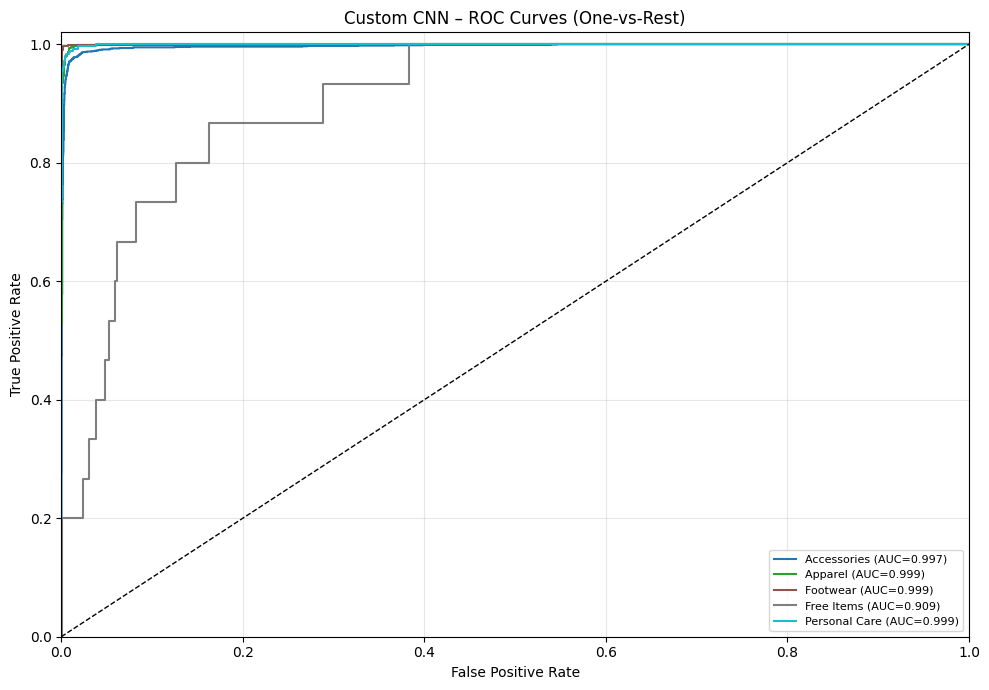

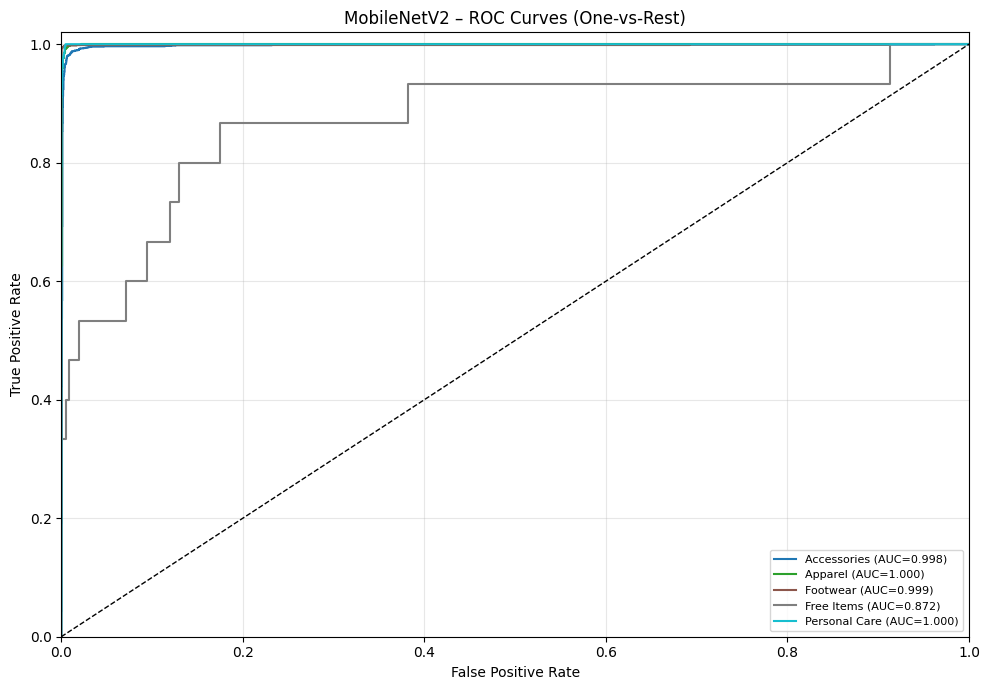

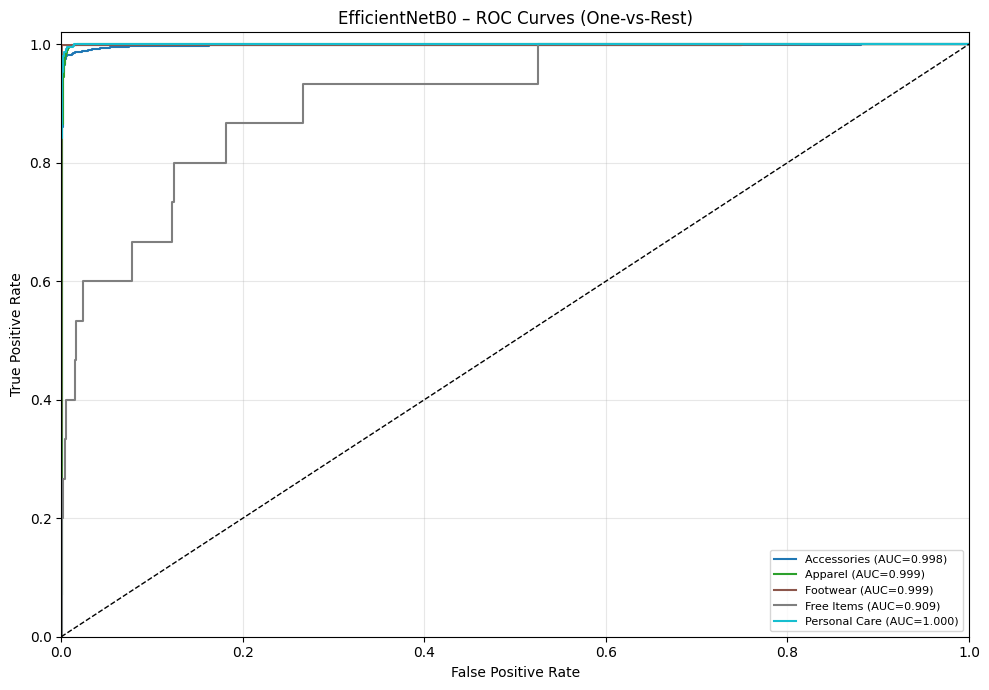

In [24]:
def plot_roc_curves(y_true, y_prob, class_names, model_name, save_path):
    """Plot One-vs-Rest ROC curves for all classes."""
    y_bin  = label_binarize(y_true, classes=list(range(len(class_names))))
    colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))

    plt.figure(figsize=(10, 7))
    for i, (cls, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=1.5, label=f'{cls} (AUC={roc_auc:.3f})')

    plt.plot([0,1],[0,1],'k--', lw=1)
    plt.xlim([0,1]); plt.ylim([0,1.02])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} – ROC Curves (One-vs-Rest)')
    plt.legend(loc='lower right', fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


plot_roc_curves(cnn_results['y_true'],          cnn_results['y_prob'],
                CLASS_NAMES, 'Custom CNN',       OUTPUT_DIR / 'cnn_roc_curves.pdf')
plot_roc_curves(mobilenet_results['y_true'],    mobilenet_results['y_prob'],
                CLASS_NAMES, 'MobileNetV2',      OUTPUT_DIR / 'mobilenet_roc_curves.pdf')
plot_roc_curves(efficientnet_results['y_true'], efficientnet_results['y_prob'],
                CLASS_NAMES, 'EfficientNetB0',   OUTPUT_DIR / 'efficientnet_roc_curves.pdf')

---
## 🔍 Step 11: Error Analysis – Misclassified Samples

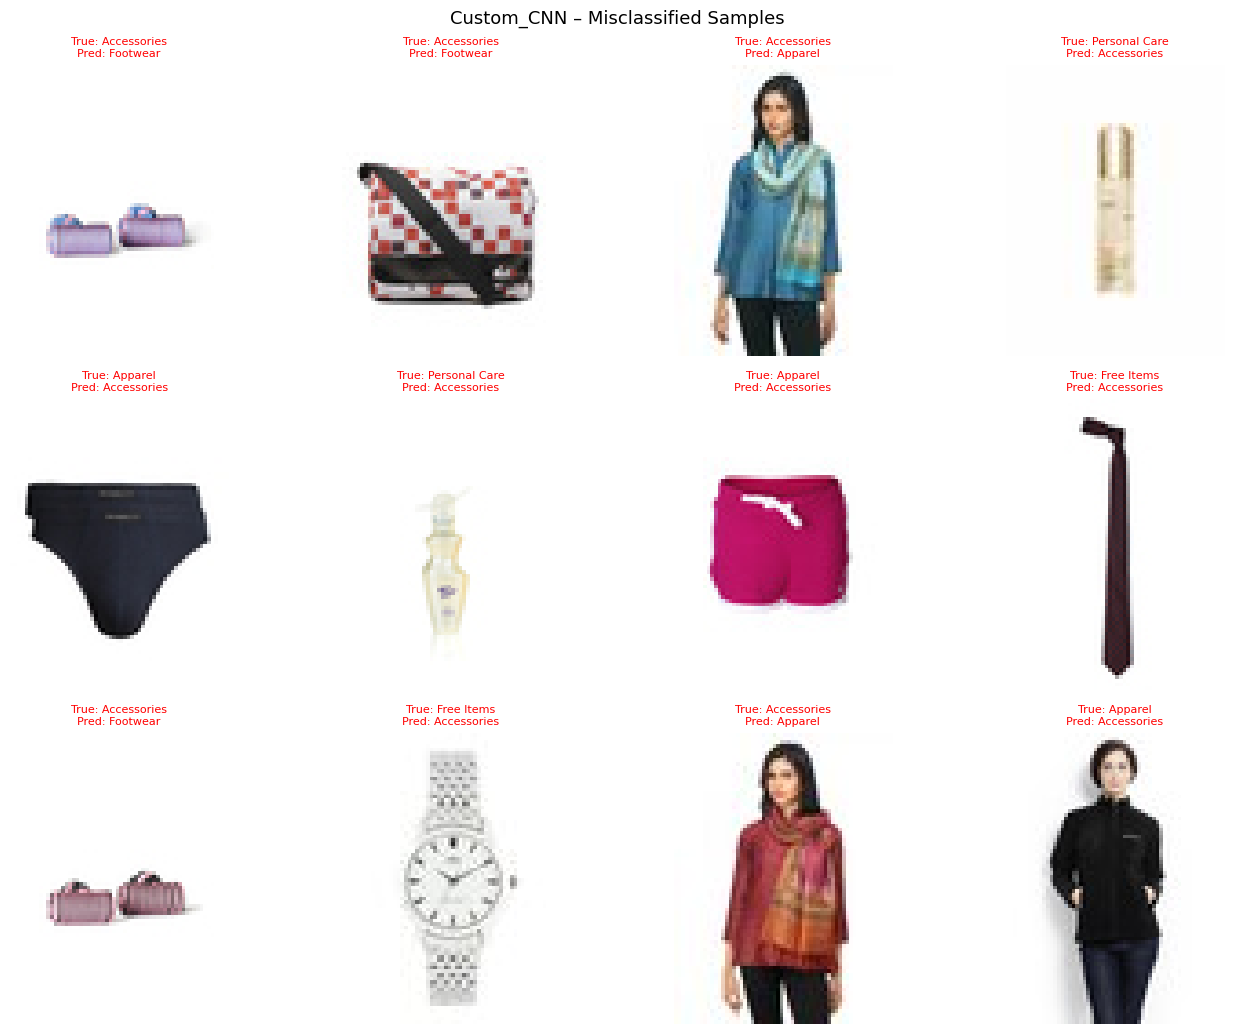

Total misclassified: 117 / 6663


In [25]:
def plot_misclassified(results, test_dataframe, class_names, model_name, output_dir, n=12):
    """Show a grid of misclassified images with true vs predicted labels."""
    y_true    = results['y_true']
    y_pred    = results['y_pred']
    wrong_idx = np.where(y_true != y_pred)[0]

    sample_idx = wrong_idx[:n] if len(wrong_idx) >= n else wrong_idx
    cols = 4
    rows = (len(sample_idx) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    axes = axes.flatten()

    for ax_i, idx in enumerate(sample_idx):
        img  = Image.open(test_dataframe.iloc[idx]['image_path']).convert('RGB')
        axes[ax_i].imshow(img)
        axes[ax_i].set_title(
            f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}",
            fontsize=8, color='red'
        )
        axes[ax_i].axis('off')

    for ax_i in range(len(sample_idx), len(axes)):
        axes[ax_i].axis('off')

    plt.suptitle(f'{model_name} – Misclassified Samples', fontsize=13)
    plt.tight_layout()
    plt.savefig(output_dir / f'{model_name}_misclassified.pdf', dpi=150)
    plt.show()
    print(f"Total misclassified: {len(wrong_idx)} / {len(y_true)}")


test_df_reset = test_df.reset_index(drop=True)
plot_misclassified(cnn_results, test_df_reset, CLASS_NAMES, 'Custom_CNN', OUTPUT_DIR)

---
## 🌡️ Step 12: Grad-CAM Visualisation (Custom CNN)

Last Conv2D layer: conv2d_6


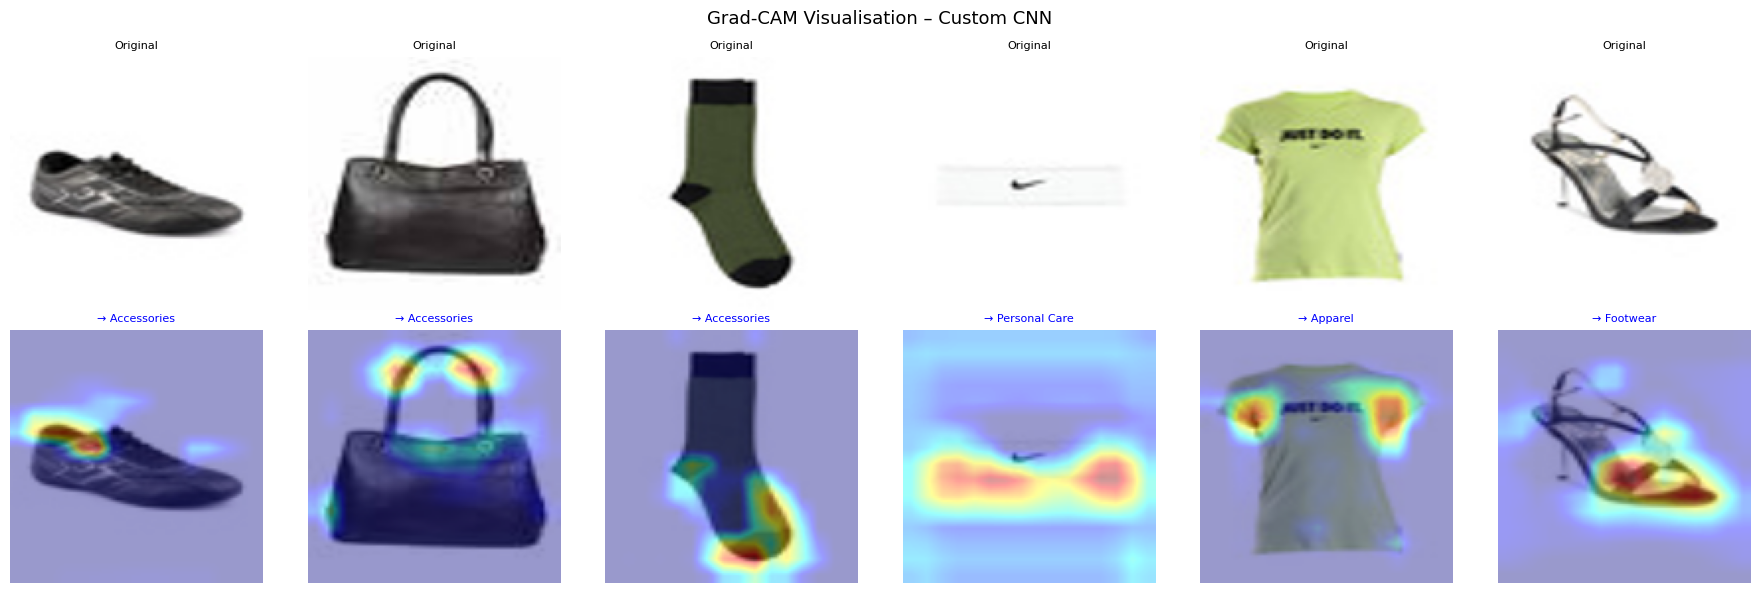

In [26]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    """
    Compute Grad-CAM heatmap using a submodel approach
    compatible with newer Keras versions.
    """
    # Create a model that outputs the last conv layer + final predictions
    last_conv_layer = model.get_layer(last_conv_layer_name)
    
    # Build feature extractor up to last conv layer
    feature_extractor = tf.keras.Sequential(
        model.layers[:model.layers.index(last_conv_layer) + 1],
        name='feature_extractor'
    )
    
    # Build classifier from after last conv to end
    classifier = tf.keras.Sequential(
        model.layers[model.layers.index(last_conv_layer) + 1:],
        name='classifier'
    )

    with tf.GradientTape() as tape:
        # Get conv features
        conv_outputs = feature_extractor(img_array)
        tape.watch(conv_outputs)
        # Get predictions from conv features
        predictions  = classifier(conv_outputs)
        pred_index   = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads        = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out     = conv_outputs[0]
    heatmap      = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)


def overlay_gradcam(img_path, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap on original image."""
    img             = cv2.imread(img_path)
    img             = cv2.resize(img, IMG_SIZE)
    heatmap_resized = cv2.resize(heatmap, IMG_SIZE)
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    heatmap_color   = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    superimposed    = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)
    return cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)


# Find name of last Conv2D layer
last_conv = [l.name for l in cnn_model.layers if isinstance(l, layers.Conv2D)][-1]
print(f"Last Conv2D layer: {last_conv}")

# Plot Grad-CAM for 6 random test images
sample_paths = test_df_reset.sample(6, random_state=SEED)['image_path'].tolist()

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col, path in enumerate(sample_paths):
    img_orig = Image.open(path).convert('RGB').resize(IMG_SIZE)
    axes[0][col].imshow(img_orig)
    axes[0][col].set_title('Original', fontsize=8)
    axes[0][col].axis('off')

    img_arr = np.expand_dims(np.array(img_orig) / 255.0, 0).astype('float32')
    heatmap, pred_idx = get_gradcam_heatmap(cnn_model, img_arr, last_conv)
    overlay = overlay_gradcam(path, heatmap)
    axes[1][col].imshow(overlay)
    axes[1][col].set_title(f'→ {CLASS_NAMES[pred_idx]}', fontsize=8, color='blue')
    axes[1][col].axis('off')

plt.suptitle('Grad-CAM Visualisation – Custom CNN', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gradcam_visualisations.pdf', dpi=150)
plt.show()

---
## 💾 Step 13: Save Models & Final Summary

In [27]:
# Save all models
cnn_model.save(          OUTPUT_DIR / 'custom_cnn_final.keras')
mobilenet_model.save(    OUTPUT_DIR / 'mobilenet_final.keras')
efficientnet_model.save( OUTPUT_DIR / 'efficientnet_final.keras')

print("Models saved.")
print(f"\nAll outputs saved to: {OUTPUT_DIR}")
print("Files:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} KB)")

Models saved.

All outputs saved to: /kaggle/working/outputs
Files:
  Custom_CNN_confusion_matrix.pdf  (16.5 KB)
  Custom_CNN_misclassified.pdf  (107.2 KB)
  Custom_CNN_report.csv  (0.3 KB)
  EfficientNetB0_confusion_matrix.pdf  (17.2 KB)
  EfficientNetB0_report.csv  (0.3 KB)
  MobileNetV2_confusion_matrix.pdf  (16.8 KB)
  MobileNetV2_report.csv  (0.3 KB)
  augmented_samples.pdf  (504.4 KB)
  best_cnn_model.keras  (7762.8 KB)
  best_efficientnet.keras  (20508.0 KB)
  best_mobilenet.keras  (25206.0 KB)
  class_distribution.pdf  (13.7 KB)
  cnn_roc_curves.pdf  (17.5 KB)
  cnn_training_curves.pdf  (15.3 KB)
  custom_cnn_final.keras  (7762.8 KB)
  efficientnet_final.keras  (20508.0 KB)
  efficientnet_roc_curves.pdf  (17.8 KB)
  efficientnet_training_curves.pdf  (14.7 KB)
  gradcam_visualisations.pdf  (588.7 KB)
  mobilenet_final.keras  (25206.0 KB)
  mobilenet_finetune_curves.pdf  (14.8 KB)
  mobilenet_roc_curves.pdf  (18.0 KB)
  mobilenet_training_curves.pdf  (14.3 KB)
  model_comparison.

In [28]:
# ── Zip all outputs ───────────────────────────────────────────────────────────
import shutil

zip_path = '/kaggle/working/project_outputs'
shutil.make_archive(zip_path, 'zip', OUTPUT_DIR)

print(f"✅ ZIP created: {zip_path}.zip")
print(f"Download it from: /kaggle/working/project_outputs.zip")

✅ ZIP created: /kaggle/working/project_outputs.zip
Download it from: /kaggle/working/project_outputs.zip


In [29]:
print("\n" + "="*60)
print("  FINAL RESULTS SUMMARY")
print("="*60)
print(comparison.to_string(index=False))
print("="*60)

best = comparison.loc[comparison['Test Accuracy'].astype(float).idxmax(), 'Model']
print(f"\n✅ Best performing model: {best}")


  FINAL RESULTS SUMMARY
         Model Test Accuracy Macro F1 Parameters
    Custom CNN        0.9824   0.7837    652,069
   MobileNetV2        0.9875   0.7869  2,587,205
EfficientNetB0        0.9886   0.7880  4,378,792

✅ Best performing model: EfficientNetB0
